# Explainability and Governance — reconstructing the allocation decision

**Purpose.** This notebook is *evidentiary*. It does not explore, tune, or compare models —
those questions were settled in Phase 5 and re-settled with a paired test in the validation-protocol
phase. It answers one question a reviewer asks: **why does the portfolio hold what it holds, and
can I check it?**

Everything below is read from `data/gold/model_explanations.json`, the committed artifact produced
by the `explainability` DVC stage. No number is recomputed here, so the notebook cannot show you
something different from what the pipeline published.

**The organising idea — two systems, two different explanations:**

| System | Method | Why |
|---|---|---|
| `regime_conditional` (reference) | Deterministic **decision trace** | It fits no predictive function over features |
| `rf_signal_tuned`, `xgb_signal_tuned` (challengers) | Exact additive **attribution** | They do fit a predictive function |

Forcing SHAP onto the reference system would produce a plausible chart that explains nothing about
how the portfolio was actually chosen. See `docs/EXPLAINABILITY.md` for the full argument.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
GOLD = ROOT / "data" / "gold"

EXPL = json.loads((GOLD / "model_explanations.json").read_text())
UNIVERSES = list(EXPL["universes"])

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, GREY, RED, GREEN = "#1F3864", "#8C8C8C", "#B03000", "#1B5E20"

print("universes:", UNIVERSES)
for u in UNIVERSES:
    print(f"  {u}: decision date {EXPL['universes'][u]['decision_date']}")
print()
for key, value in EXPL["explanation_policy"].items():
    print(f"{key:22s} {value}")

universes: ['etf_2017', 'full_2021']
  etf_2017: decision date 2026-07-24
  full_2021: decision date 2026-07-24

causality              No explanation in this artifact supports a causal claim.
challenger_method      exact additive tree contributions + seeded permutation importance
primary_method         deterministic decision trace (fits no predictive function)
primary_system         regime_conditional
shap_package_used      False
shap_rationale         xgboost ships TreeSHAP natively and scikit-learn's tree API supports the exact path decomposition, so exact attribution needs no extra dependency; `shap` would add a numba/llvmlite native stack to a project that already withdrew a model over a native-library conflict.


## 1. The decision trace

Seven steps, each a function of data available at the decision date τ. This is the whole
explanation of the reference system — there is no hidden model behind it.

In [2]:
def show_trace(universe: str) -> None:
    t = EXPL["universes"][universe]["primary"]
    hmm, dec, con = t["hmm"], t["decision"], t["constraints"]

    print(f"{'='*74}\n{universe}  —  decision date {t['decision_date']}  ({t['n_assets']} assets)\n{'='*74}")
    print("1. HMM inputs at tau")
    for name, value in hmm["inputs_at_decision_date"].items():
        print(f"      {name:22s} {value:+.6f}")

    print(f"\n2. Posterior       {hmm['posterior']}")
    print(f"   converged       {hmm['converged']}   log-likelihood {hmm['log_likelihood']:.1f}"
          f"   winning seed {hmm['seed_used']}")
    print(f"   state -> label  {hmm['state_label_map']}")

    print(f"\n3. Selected regime      {dec['selected_regime'].upper()}")
    print(f"4. Sub-optimizer        {dec['selected_sub_optimizer']}"
          f"   (bull={dec['bull_sub_optimizer']}, bear={dec['bear_sub_optimizer']})")

    m = t["moment_inputs"]
    print(f"\n5. Moment inputs        covariance={m['covariance_estimator']}, "
          f"{m['training_rows']} rows from {m['training_start']}")

    print(f"\n6. Binding constraints  cap={con['max_weight']:.0%}, long-only={con['long_only']}")
    print(f"      at cap  ({con['n_binding_at_cap']}): {con['assets_at_cap']}")
    print(f"      at zero      : {con['assets_at_zero']}")
    print(f"      {con['binding_note']}")

    print(f"\n7. Weights              " + "  ".join(f"{a}={w:.3f}" for a, w in sorted(t['weights'].items())))
    print(f"\n   fallback_used        {t['fallback_used']}")
    if t["fallback_reason"]:
        print(f"   reason               {t['fallback_reason']}")
    print()

for u in UNIVERSES:
    show_trace(u)

etf_2017  —  decision date 2026-07-24  (5 assets)
1. HMM inputs at tau
      AVG_PAIRWISE_CORR      +0.595962
      MARKET_RETURN          +0.000000
      MARKET_VOL_SHORT       +0.141904

2. Posterior       {'bear': 0.9999663886711322, 'bull': 3.361132957125849e-05}
   converged       True   log-likelihood -18833.8   winning seed 4
   state -> label  {'0': 'bear', '1': 'bull'}

3. Selected regime      BEAR
4. Sub-optimizer        min_variance_lw   (bull=max_sharpe, bear=min_variance_lw)

5. Moment inputs        covariance=ledoit_wolf, 5656 rows from 2004-11-19

6. Binding constraints  cap=25%, long-only=True
      at cap  (4): ['SPY', 'QQQ', 'GLD', 'TLT']
      at zero      : ['EEM']
      5 assets x 25% cap = 1.25. When this product is close to 1, every feasible long-only portfolio must hold most assets at the cap, so the CONSTRAINT rather than the covariance model determines the allocation.

7. Weights              EEM=0.000  GLD=0.250  QQQ=0.250  SPY=0.250  TLT=0.250

   fallback_u

### What the trace already tells us

Both universes are in the **bear** state at this rebalance, so both delegate to
`min_variance_lw` — the defensive branch. That is a single line of evidence, but it is the
kind a risk reviewer can actually check: the posterior, the seed that won the restart
competition, and the state→label mapping are all in the artifact.

The mapping matters more than it looks. `hmmlearn` does not guarantee stable state ordering
across fits, so "state 0" means nothing on its own. States are mapped to bull/bear by ranking
each state's fitted `MARKET_RETURN` mean, **recomputed at every refit**.

## 2. The binding constraint — the project's most important caveat

On a small universe a long-only weight cap can determine the allocation almost by itself.
With $n$ assets and a cap $c$, every feasible portfolio must hold at least $\lceil 1/c \rceil$
assets, and when $n \times c$ approaches 1 there is almost no freedom left to express a view.

This is why a conclusion of the form *"model X adds no value on `etf_2017`"* has to be read
carefully: the optimizer may simply have had nowhere to put a view.

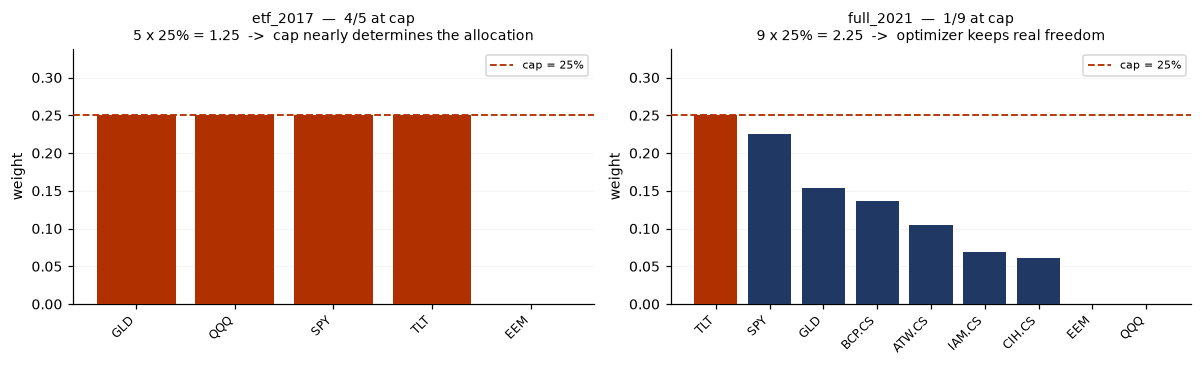

etf_2017     cap_is_near_determining = True
full_2021    cap_is_near_determining = False


In [3]:
fig, axes = plt.subplots(1, len(UNIVERSES), figsize=(11, 3.4))
for ax, universe in zip(np.atleast_1d(axes), UNIVERSES):
    t = EXPL["universes"][universe]["primary"]
    con = t["constraints"]
    weights = pd.Series(t["weights"]).sort_values(ascending=False)
    at_cap = set(con["assets_at_cap"])
    colours = [RED if a in at_cap else BLUE for a in weights.index]

    ax.bar(range(len(weights)), weights.to_numpy(), color=colours, zorder=3)
    ax.axhline(con["max_weight"], color=RED, ls="--", lw=1.2, zorder=4,
               label=f"cap = {con['max_weight']:.0%}")
    ax.set_xticks(range(len(weights)))
    ax.set_xticklabels(weights.index, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("weight")
    ax.set_ylim(0, con["max_weight"] * 1.35)
    product = t["n_assets"] * con["max_weight"]
    verdict = "cap nearly determines the allocation" if con["cap_is_near_determining"] else "optimizer keeps real freedom"
    ax.set_title(f"{universe}  —  {con['n_binding_at_cap']}/{t['n_assets']} at cap\n"
                 f"{t['n_assets']} x {con['max_weight']:.0%} = {product:.2f}  ->  {verdict}", fontsize=9)
    ax.legend(fontsize=7.5, loc="upper right")
    ax.grid(axis="y", alpha=0.18, lw=0.5)
plt.tight_layout()
plt.show()

for universe in UNIVERSES:
    con = EXPL["universes"][universe]["primary"]["constraints"]
    print(f"{universe:12s} cap_is_near_determining = {con['cap_is_near_determining']}")

**Read the two panels side by side.** On `etf_2017` four of five assets sit exactly on the cap
and the fifth is at zero — there is essentially one feasible shape of portfolio, and the
covariance model chooses only which asset to drop. On `full_2021`, nine assets against the same
cap leave the optimizer genuine freedom, and the weights are spread.

This is *not* an argument that the cap is a mistake. It is the reason the constraint is reported
as a first-class field of every decision rather than left for a reader to infer.

## 3. Challenger attribution — global importance

One seeded permutation procedure for both model families, so these rankings **are** comparable
across models. The metric is the mean increase in MSE when a single feature is shuffled.

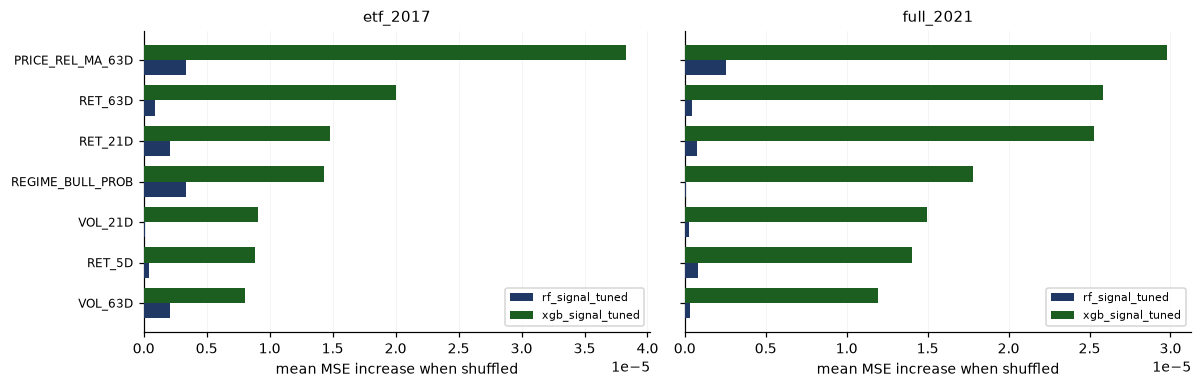

universe                etf_2017                        full_2021                 
model            rf_signal_tuned xgb_signal_tuned rf_signal_tuned xgb_signal_tuned
feature                                                                           
PRICE_REL_MA_63D             3.0              3.0             1.0              1.0
REGIME_BULL_PROB             7.0              5.0             7.0              4.0
RET_21D                      4.0              7.0             3.0              3.0
RET_5D                       1.0              4.0             2.0              6.0
RET_63D                      6.0              6.0             4.0              2.0
VOL_21D                      2.0              1.0             6.0              5.0
VOL_63D                      5.0              2.0             5.0              7.0


In [4]:
rows = []
for universe in UNIVERSES:
    for name, block in EXPL["universes"][universe]["challengers"].items():
        if "unavailable" in block:
            print(f"{universe} / {name}: unavailable — {block['unavailable']}")
            continue
        for entry in block["global_importance_permutation"]:
            rows.append({"universe": universe, "model": name,
                         "feature": entry["feature"], "mse_increase": entry["mse_increase"],
                         "rank": entry["rank"]})
importance = pd.DataFrame(rows)

fig, axes = plt.subplots(1, len(UNIVERSES), figsize=(11, 3.6), sharey=True)
for ax, universe in zip(np.atleast_1d(axes), UNIVERSES):
    sub = importance[importance.universe == universe]
    features = (sub.groupby("feature")["mse_increase"].max().sort_values().index.tolist())
    width, offset = 0.38, {"rf_signal_tuned": -0.19, "xgb_signal_tuned": +0.19}
    for model, colour in (("rf_signal_tuned", BLUE), ("xgb_signal_tuned", GREEN)):
        s = sub[sub.model == model].set_index("feature").reindex(features)["mse_increase"]
        ax.barh(np.arange(len(features)) + offset[model], s.to_numpy(),
                height=width, color=colour, label=model, zorder=3)
    ax.set_yticks(range(len(features)))
    ax.set_yticklabels(features, fontsize=8)
    ax.set_xlabel("mean MSE increase when shuffled")
    ax.set_title(universe, fontsize=9.5)
    ax.grid(axis="x", alpha=0.18, lw=0.5)
    ax.legend(fontsize=7.5, loc="lower right")
plt.tight_layout()
plt.show()

print(importance.pivot_table(index="feature", columns=["universe", "model"],
                             values="rank").to_string())

Two things worth noting, and the second is a limitation rather than a result.

`PRICE_REL_MA_63D` — price relative to its 63-day moving average — ranks first for both models on
both universes. `REGIME_BULL_PROB` is used but is not dominant, which answers a question left open
in Phase 4B: the models do consult the regime feature rather than ignoring it.

**The absolute values are tiny.** That is the honest state of cross-sectional return prediction on
this data and it matches the small information coefficients Phase 5 measured. Read the chart as a
*ranking*, not as a variance decomposition — and note that permutation importance understates
correlated features, which trailing returns over overlapping windows certainly are.

## 4. Local contributions — exact and additive

For a single prediction, how much did each feature contribute? Both methods here are **exact**:
`bias + Σ contributions = prediction`, to float precision. That is what makes the reconstruction
check below a genuine assertion rather than a tolerance to be tuned.

No `shap` dependency: XGBoost ships TreeSHAP natively, and scikit-learn's tree API supports the
exact path decomposition in about thirty lines.

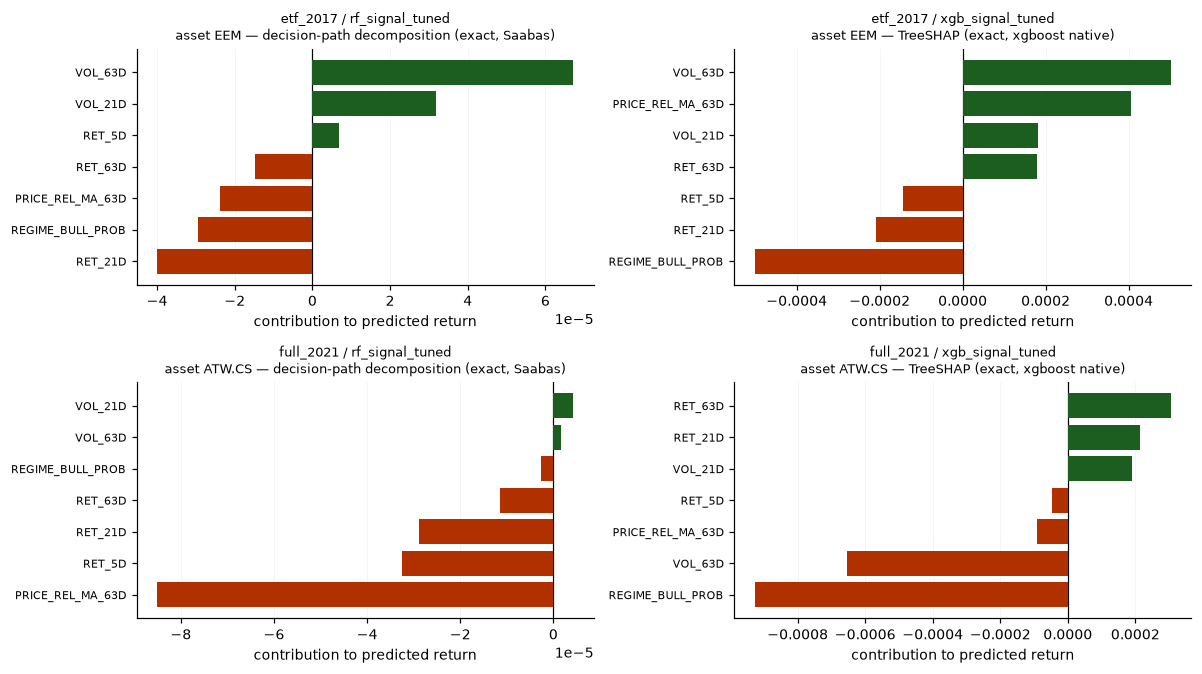

 universe            model  asset       bias  sum_contributions  prediction  reconstruction_error
 etf_2017  rf_signal_tuned    EEM  3.282e-04         -2.016e-06   3.262e-04             1.626e-19
 etf_2017 xgb_signal_tuned    EEM  3.380e-04          4.150e-04   7.530e-04             5.821e-11
full_2021  rf_signal_tuned ATW.CS  2.279e-04         -1.545e-04   7.339e-05             9.487e-20
full_2021 xgb_signal_tuned ATW.CS  2.353e-04         -1.008e-03  -7.732e-04             4.220e-10

additivity holds everywhere: True


In [5]:
fig, axes = plt.subplots(len(UNIVERSES), 2, figsize=(11, 3.1 * len(UNIVERSES)))
axes = np.atleast_2d(axes)
checks = []

for row, universe in enumerate(UNIVERSES):
    for col, model in enumerate(("rf_signal_tuned", "xgb_signal_tuned")):
        ax = axes[row, col]
        block = EXPL["universes"][universe]["challengers"].get(model, {})
        if "unavailable" in block:
            ax.set_axis_off(); continue
        local = block["local_contributions"]
        contribs = pd.Series(local["contributions"]).sort_values()
        ax.barh(range(len(contribs)), contribs.to_numpy(),
                color=[GREEN if v >= 0 else RED for v in contribs], zorder=3)
        ax.set_yticks(range(len(contribs)))
        ax.set_yticklabels(contribs.index, fontsize=7.5)
        ax.axvline(0, color="black", lw=0.8)
        ax.set_title(f"{universe} / {model}\nasset {local['asset']} — {local['method']}", fontsize=8.5)
        ax.set_xlabel("contribution to predicted return")
        ax.grid(axis="x", alpha=0.18, lw=0.5)
        checks.append({
            "universe": universe, "model": model, "asset": local["asset"],
            "bias": local["bias"], "sum_contributions": float(sum(local["contributions"].values())),
            "prediction": local["prediction"], "reconstruction_error": local["reconstruction_error"],
        })
plt.tight_layout()
plt.show()

audit = pd.DataFrame(checks)
print(audit.to_string(index=False, float_format=lambda v: f"{v: .3e}"))
print("\nadditivity holds everywhere:", bool((audit.reconstruction_error < 1e-5).all()))

The `reconstruction_error` column is the self-check: `bias + Σ contributions − prediction`. It sits
at float noise for every row, which is the property the two exact algorithms guarantee and
`tests/test_explainability.py` asserts.

The trade-off being accepted: the two model families use **different** exact algorithms, so
contribution *magnitudes* are not comparable across models. Rankings within a model are, and the
global importance above is comparable across both.

## 5. From predicted ranking to actual weights

The step most often left implicit. A model can rank assets well and still produce weights that
ignore the ranking, because the covariance term and the weight cap both intervene between the
prediction and the portfolio.

 universe            model  rank_concordance undefined_reason
 etf_2017  rf_signal_tuned         -1.000000             None
 etf_2017 xgb_signal_tuned          0.894427             None
full_2021  rf_signal_tuned          0.466102             None
full_2021 xgb_signal_tuned          0.690066             None


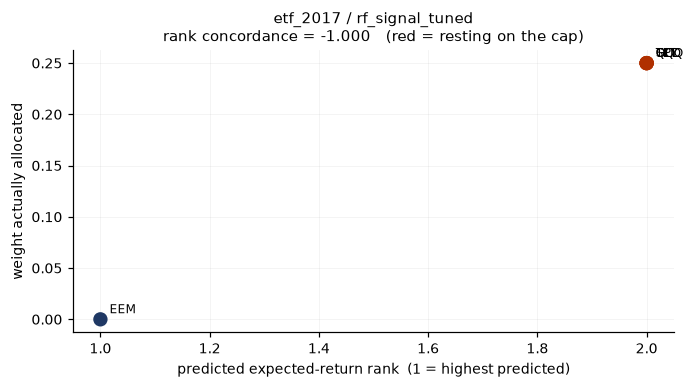

    predicted_expected_return predicted_rank weight weight_rank at_cap
EEM                  0.000326              1    0.0           5  False
GLD                  0.000271              2   0.25           1   True
QQQ                  0.000271              2   0.25           1   True
SPY                  0.000271              2   0.25           1   True
TLT                  0.000271              2   0.25           1   True


In [6]:
summary = []
for universe in UNIVERSES:
    for model, block in EXPL["universes"][universe]["challengers"].items():
        if "unavailable" in block:
            continue
        link = block["ranking_to_weights"]
        summary.append({
            "universe": universe, "model": model,
            "rank_concordance": link["rank_concordance_spearman"],
            "undefined_reason": link["concordance_undefined_reason"],
        })
concordance = pd.DataFrame(summary)
print(concordance.to_string(index=False))

worst = concordance.dropna(subset=["rank_concordance"]).nsmallest(1, "rank_concordance").iloc[0]
link = EXPL["universes"][worst.universe]["challengers"][worst.model]["ranking_to_weights"]
frame = pd.DataFrame(link["per_asset"]).T.sort_values("predicted_rank")

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.scatter(frame["predicted_rank"].astype(float), frame["weight"].astype(float),
           s=70, color=[RED if c else BLUE for c in frame["at_cap"]], zorder=3)
for asset, r in frame.iterrows():
    ax.annotate(asset, (float(r["predicted_rank"]), float(r["weight"])),
                xytext=(6, 4), textcoords="offset points", fontsize=8)
ax.set_xlabel("predicted expected-return rank  (1 = highest predicted)")
ax.set_ylabel("weight actually allocated")
ax.set_title(f"{worst.universe} / {worst.model}\n"
             f"rank concordance = {worst.rank_concordance:+.3f}   "
             f"(red = resting on the cap)", fontsize=9.5)
ax.grid(alpha=0.18, lw=0.5)
plt.tight_layout()
plt.show()

print(frame[["predicted_expected_return", "predicted_rank", "weight", "weight_rank", "at_cap"]].to_string())

**This is the notebook's sharpest finding.** A rank concordance of **−1.000** means the allocation
is the exact reverse of the predicted ranking: the asset the model likes most receives **zero
weight**.

That is not a bug, and it is not evidence the model is broken. The optimizer trades predicted
return against covariance under a binding cap, and on a five-asset universe the cap dominates
everything else. But it is precisely the kind of behaviour that stays invisible when a strategy is
judged only by its Sharpe ratio — and it is a concrete illustration of why *prediction accuracy ≠
portfolio performance*, the empirical ceiling this project hit three independent times.

One reporting detail: concordance is `null`, **not** `0.0`, when a fully binding cap gives every
asset the same weight. Reporting zero would read as "the weights ignore the ranking" when the truth
is that the constraint left no ordering to express.

## 6. What is checked, and what is not claimed

`tests/test_explainability.py` locks in the properties this notebook relies on:

| Rule | How |
|---|---|
| The trace reads no row after τ | Corrupt the **future** of both input frames; the decision must be unchanged |
| Explanations are reproducible | Repeated calls must be identical; permutation importance is explicitly seeded |
| Contributions are internally consistent | `bias + Σ contributions = prediction` |
| Feature names match the training matrix | Contribution keys compared against the model's own columns |
| A binding cap is detected by tolerance, not equality | SLSQP returns a converged optimum, not an exact boundary value |
| An uncertain regime resolves defensively, and says so | Below the history floor the trace must name the fallback |

### Not claimed

- **Attribution is not causation.** Every method here describes what a fitted function does with
  its inputs. None identifies a cause of a market return.
- **No outperformance is established.** Both challengers explained above failed to establish
  statistically supported outperformance against `regime_conditional` or against equal weighting in
  the paired bootstrap. Their model cards say so.
- **This is a research prototype.** Not production-approved, not investment advice. See
  `docs/MODEL_GOVERNANCE.md`, whose most important line is that no independent validation function
  has reviewed any of this.